# Regressão Linear - Fundamentos
**Autor: Wellington M Santos - Data Scientist**  
[![LinkedIn](https://img.shields.io/badge/LinkedIn-wellington--moreira--santos-blue)](https://www.linkedin.com/in/wellington-moreira-santos)
[![Email](https://img.shields.io/badge/Email-wsantos08%40hotmail.com-red)](mailto:wsantos08@hotmail.com)

## 1. Introdução

Aí você se pega tentando adivinhar o preço de um apartamento. Você sabe que ele tem 80 m², está no centro da cidade e foi construído há 5 anos. Intuitivamente, você já está fazendo algum tipo de raciocínio: "apartamentos maiores costumam custar mais, localização boa encarece, construção nova vale mais..."

Esse raciocínio, quando formalizado matematicamente, é exatamente o que a regressão linear faz.

A ideia central é simples: **encontrar uma reta que represente a relação entre uma ou mais informações que você tem (as entradas) e um valor que você quer prever (a saída)**. Com essa reta em mãos, dado qualquer nova entrada, você consegue fazer uma previsão razoável da saída.

Parece modesto, mas não subestime: regressão linear está por trás de modelos de precificação de imóveis, análise de risco de crédito, previsão de demanda em varejo e até do modelo financeiro mais famoso da história moderna, o CAPM. Ela é o ponto de partida honesto para qualquer pessoa que quer entender machine learning de verdade, sem pular etapas.

Neste material, você vai entender o que a regressão linear faz, por que ela funciona dessa forma e como implementá-la do zero usando Python puro. Sem mágica, sem caixa-preta.

**O que você vai aprender neste notebook:**

1. Introdução
2. Imports e Configurações
3. O Problema: Por Que Precisamos de uma Reta?
4. A Equação da Reta
5. Como Encontrar a Melhor Reta
6. O Que São Resíduos?
7. Implementando do Zero com NumPy
8. Visualizando o Resultado
9. Conclusão

## 2. Imports e Configurações

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Configurações visuais para os gráficos ficarem mais limpos
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(' - BIBLIOTECAS CARREGADAS - ')

 - BIBLIOTECAS CARREGADAS - 


Nesta parte, vamos usar apenas NumPy e Matplotlib. Nada de scikit-learn ainda, porque o objetivo aqui é entender o que acontece por baixo dos panos antes de usar ferramentas prontas. Isso vai fazer toda a diferença mais adiante.

## 3. Por Que Precisamos de uma Reta?

Vamos começar com um exemplo concreto e pequeno.

Suponha que você coletou dados de 10 apartamentos: o tamanho de cada um (em m²) e o preço de aluguel (em reais). Você quer saber: **existe uma relação entre tamanho e preço? E se existe, como usar essa relação para prever o aluguel de um apartamento novo?**


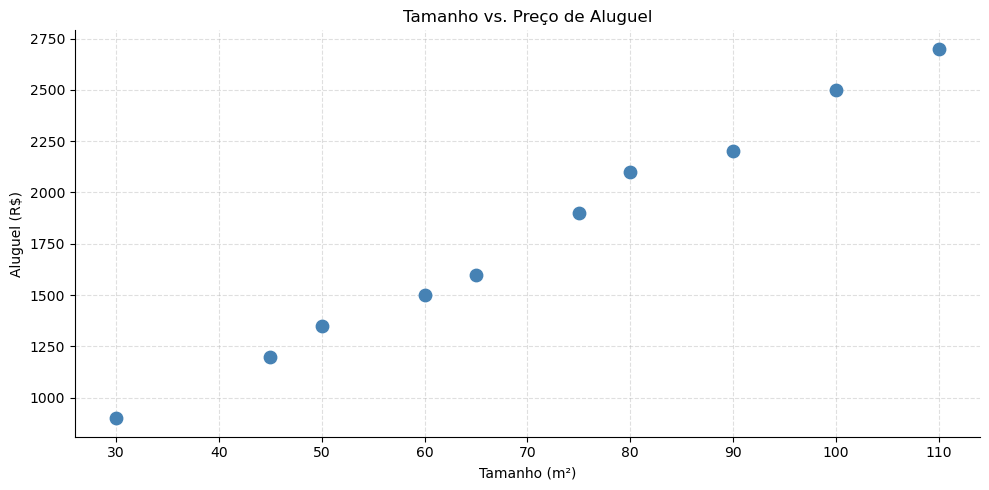

In [3]:
# Dados fictícios: tamanho (m²) e preço de aluguel (R$)
tamanho = np.array([30, 45, 50, 60, 65, 75, 80, 90, 100, 110])
aluguel = np.array([900, 1200, 1350, 1500, 1600, 1900, 2100, 2200, 2500, 2700])

# Vamos visualizar esses dados primeiro
plt.figure()
plt.scatter(tamanho, aluguel, color='steelblue', s=80, zorder=3)
plt.xlabel('Tamanho (m²)')
plt.ylabel('Aluguel (R$)')
plt.title('Tamanho vs. Preço de Aluguel')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


Olhando o gráfico, você provavelmente já consegue ver a tendência: **quanto maior o apartamento, maior o aluguel**. Os pontos sobem da esquerda para a direita de forma bastante consistente.

Agora vem a pergunta natural: **e se eu traçar uma reta no meio desses pontos?** Essa reta poderia capturar essa tendência e, para qualquer tamanho novo que eu der a ela, ela me devolve uma estimativa de aluguel.

Mas não basta qualquer reta. Existem infinitas retas que passam por esse gráfico. Qual delas é a **melhor**? É exatamente isso que a regressão linear resolve.



## 4. A Equação da Reta

Antes de falar em "melhor reta", precisamos ter clareza sobre o que é uma reta matematicamente.

Se você lembra das aulas de ensino médio, a equação de uma reta é:

$$y = a \cdot x + b$$

Onde:
- **$x$** é o valor de entrada (no nosso caso, o tamanho do apartamento)
- **$y$** é o valor de saída (o aluguel previsto)
- **$a$** é o coeficiente angular: diz o quanto $y$ muda para cada unidade a mais em $x$. Se $a = 20$, significa que cada m² extra adiciona R$ 20 ao aluguel
- **$b$** é o intercepto: é o valor de $y$ quando $x = 0$. No contexto de apartamentos, não tem interpretação direta (um apartamento de 0 m² não existe), mas faz parte da equação

Em machine learning e estatística, é mais comum escrever assim:

$$\hat{y} = \beta_0 + \beta_1 \cdot x$$

O $\hat{y}$ (lê-se "y-chapéu") significa "valor previsto de y". O "chapéu" serve exatamente para lembrar que é uma previsão, não o valor real. $\beta_0$ é o intercepto e $\beta_1$ é o coeficiente angular.

**A tarefa da regressão linear é descobrir os valores de $\beta_0$ e $\beta_1$ que fazem essa reta se ajustar melhor aos dados.**




## 5. Como Encontrar a Melhor Reta

Aqui está o coração da regressão linear. Vamos pensar juntos.

Você tem seus dados (os pontos no gráfico) e uma reta candidata. Para saber se essa reta é boa ou ruim, você precisa de alguma forma de **medir o erro**: a diferença entre o que a reta prevê e o que os dados realmente mostram.

Para cada ponto $(x_i, y_i)$ nos seus dados, a reta faz uma previsão $\hat{y}_i$. O erro desse ponto é:

$$\text{erro}_i = y_i - \hat{y}_i$$

Se o aluguel real é R$ 1.500 e a reta previu R$ 1.300, o erro é +200. Se a reta previu R$ 1.700, o erro é -200.

Agora, como resumir todos esses erros em um único número que diga "essa reta é boa" ou "essa reta é ruim"?

A ideia mais natural seria somar todos os erros. Mas tem um problema: erros positivos e negativos se cancelam. Uma reta que erra +500 num ponto e -500 noutro teria soma de erros igual a zero, como se fosse perfeita. O que claramente não é.

A solução adotada pela regressão linear é **elevar cada erro ao quadrado antes de somar**. Isso resolve o problema do cancelamento e, de bônus, penaliza erros grandes de forma mais severa do que erros pequenos:

$$\text{Soma dos Quadrados dos Resíduos} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Esse valor é chamado de **RSS** (do inglês *Residual Sum of Squares*). **Quanto menor o RSS, melhor a reta se ajusta aos dados.**

O método que minimiza o RSS tem um nome: **Mínimos Quadrados Ordinários**, ou OLS (*Ordinary Least Squares*). É o coração matemático da regressão linear.



### 5.1 A Fórmula dos Coeficientes

Para não deixar no ar, os valores de $\beta_0$ e $\beta_1$ que minimizam o RSS têm fórmulas fechadas. Isso significa que não precisamos de nenhum processo iterativo, apenas calcular:

$$\beta_1 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

$$\beta_0 = \bar{y} - \beta_1 \cdot \bar{x}$$

Onde $\bar{x}$ e $\bar{y}$ são as médias de $x$ e $y$, respectivamente.

Pode parecer intimidador à primeira vista, mas vamos decompor:

- O numerador de $\beta_1$ mede o quanto $x$ e $y$ variam **juntos** (quando $x$ está acima da média, $y$ também tende a estar?)
- O denominador mede o quanto $x$ varia **sozinho**
- A divisão normaliza essa covariação pela variabilidade de $x$, resultando na inclinação da reta

Uma forma mais curta de escrever isso, usando estatística:

$$\beta_1 = \frac{\text{Cov}(x, y)}{\text{Var}(x)}$$




## 6. O Que São Resíduos?

Você já viu o termo "resíduos" aparecer. Vale explicar com cuidado porque ele vai aparecer muito ao longo deste material.

**Resíduo** é a diferença entre o valor real e o valor previsto pelo modelo para um determinado ponto:

$$\varepsilon_i = y_i - \hat{y}_i$$

Visualmente, o resíduo é o **segmento vertical** que vai do ponto real até a reta. Se o ponto está acima da reta, o resíduo é positivo. Se está abaixo, é negativo.


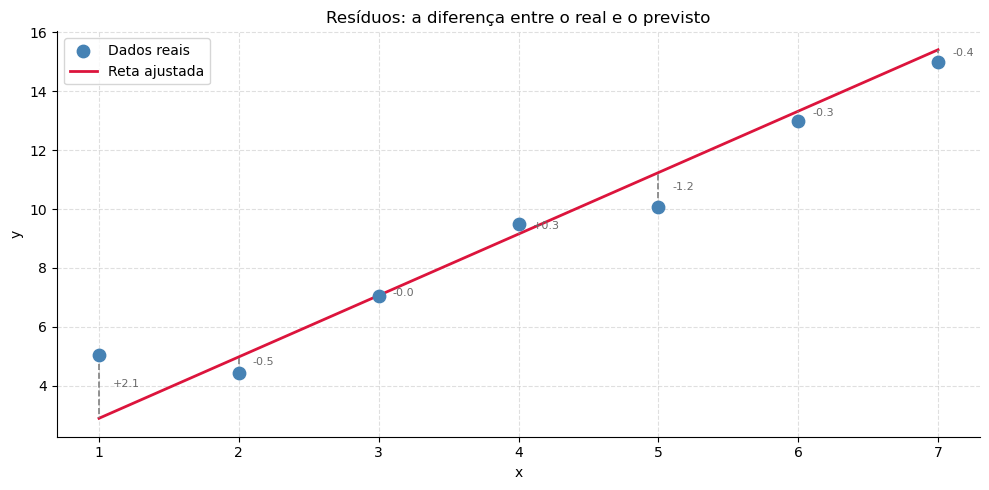

In [4]:
# Gerando dados para ilustrar resíduos
np.random.seed(7)
x_ex = np.array([1, 2, 3, 4, 5, 6, 7], dtype=float)
y_ex = 2 * x_ex + 1 + np.random.normal(0, 1.2, len(x_ex))

# Calculando a reta (manualmente, como faremos na seção seguinte)
beta1 = np.cov(x_ex, y_ex)[0, 1] / np.var(x_ex)
beta0 = np.mean(y_ex) - beta1 * np.mean(x_ex)
y_pred_ex = beta0 + beta1 * x_ex

# Plot com resíduos
plt.figure()
plt.scatter(x_ex, y_ex, color='steelblue', s=80, zorder=3, label='Dados reais')
plt.plot(x_ex, y_pred_ex, color='crimson', linewidth=2, label='Reta ajustada')

for i in range(len(x_ex)):
    plt.plot(
        [x_ex[i], x_ex[i]],
        [y_ex[i], y_pred_ex[i]],
        color='gray', linestyle='--', linewidth=1.2
    )
    residuo = y_ex[i] - y_pred_ex[i]
    plt.annotate(
        f'{residuo:+.1f}',
        xy=(x_ex[i] + 0.1, (y_ex[i] + y_pred_ex[i]) / 2),
        fontsize=8, color='dimgray'
    )

plt.xlabel('x')
plt.ylabel('y')
plt.title('Resíduos: a diferença entre o real e o previsto')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

> Cada segmento vertical cinza é um resíduo. O número anotado ao lado é o valor desse resíduo: positivo quando o ponto real está acima da reta, negativo quando está abaixo. A reta ajustada é aquela que minimiza a soma dos quadrados desses segmentos.

Um detalhe importante: a regressão linear **não zera os resíduos**, ela os **minimiza**. Zerá-los seria overfitting.


## 6.1 Entendendo a lógica utilizada nesta seção 

O código desta seção tem três responsabilidades distintas: 
- gerar dados simples para ilustrar o conceito, 
- calcular a reta que melhor se ajusta a esses dados e, por fim,
- desenhar os resíduos como segmentos verticais sobre o gráfico.

A primeira parte cria os dados de exemplo. 
- `x_ex` é uma sequência de sete pontos igualmente espaçados de 1 a 7. 
- `y_ex` é gerado a partir de uma relação linear conhecida, `2 * x + 1`, com um ruído aleatório adicionado via `np.random.normal(0, 1.2, ...)`. 

Esse ruído simula o que acontece em dados reais, ou seja, a relação existe, mas não é perfeita. Os pontos não vão cair exatamente sobre a reta.

A segunda parte calcula os coeficientes da reta. Aqui o código usa diretamente as
fórmulas que acabamos de derivar:
-  `np.cov(x_ex, y_ex)[0, 1]` extrai a covariância entre `x` e `y` da matriz de covariância retornada pelo NumPy (o `[0, 1]` pega o
elemento fora da diagonal, que é justamente a covariância cruzada), 
- e `np.var(x_ex)` calcula a variância de `x`. 

A divisão entre os dois dá `beta1`, e `beta0` é calculado pela fórmula do intercepto, já `y_pred_ex` são os valores que a reta
prevê para cada ponto de `x_ex`.

A terceira parte monta o gráfico. 
- O `plt.scatter` plota os pontos reais em azul. 
- O `plt.plot` traça a reta ajustada em vermelho. 
- O `for` percorre cada ponto e desenha um segmento vertical cinza conectando o valor real (`y_ex[i]`) ao valor previsto pela reta (`y_pred_ex[i]`): esse segmento é o resíduo visualizado. 
- O `plt.annotate` coloca o valor numérico do resíduo ao lado de cada segmento, com sinal positivo ou negativo, para deixar explícito o quanto o modelo errou em cada ponto e em qual direção.

## 7. Implementando do Zero com NumPy

Chega de teoria. Vamos colocar tudo isso em código.


In [5]:
def calcular_coeficientes(x, y):
    """
    Calcula os coeficientes β₀ e β₁ da regressão linear simples
    usando as fórmulas de Mínimos Quadrados Ordinários.

    Parâmetros:
        x: array com os valores da variável independente
        y: array com os valores da variável dependente

    Retorna:
        beta0: intercepto
        beta1: coeficiente angular
    """
    x_media = np.mean(x)
    y_media = np.mean(y)

    # Numerador: como x e y variam juntos (covariância não normalizada)
    numerador = np.sum((x - x_media) * (y - y_media))

    # Denominador: quanto x varia sozinho (variância não normalizada)
    denominador = np.sum((x - x_media) ** 2)

    beta1 = numerador / denominador
    beta0 = y_media - beta1 * x_media

    return beta0, beta1


def prever(x, beta0, beta1):
    """
    Faz previsões usando os coeficientes calculados.
    """
    return beta0 + beta1 * x


Agora vamos aplicar ao nosso exemplo de apartamentos:


In [6]:

# Calculando os coeficientes
beta0, beta1 = calcular_coeficientes(tamanho, aluguel)

print(f"Intercepto (β₀): R$ {beta0:.2f}")
print(f"Coeficiente angular (β₁): R$ {beta1:.2f} por m²")
print()
print("Interpretação:")
print(f"  → Cada m² adicional está associado a um aumento de R$ {beta1:.2f} no aluguel.")
print(f"  → O intercepto de R$ {beta0:.2f} é o valor base da equação (sem interpretação direta aqui).")

Intercepto (β₀): R$ 176.46
Coeficiente angular (β₁): R$ 22.96 por m²

Interpretação:
  → Cada m² adicional está associado a um aumento de R$ 22.96 no aluguel.
  → O intercepto de R$ 176.46 é o valor base da equação (sem interpretação direta aqui).


In [8]:
# Fazendo previsões para os dados de treinamento
aluguel_previsto = prever(tamanho, beta0, beta1)

# Calculando os resíduos
residuos = aluguel - aluguel_previsto

# Mostrando o resultado ponto a ponto
print(f"{'Tamanho':>10} {'Aluguel Real':>15} {'Previsto':>15} {'Resíduo':>12}")
print("-" * 55)
for i in range(len(tamanho)):
    print(f"{tamanho[i]:>10.0f} {aluguel[i]:>15.0f} {aluguel_previsto[i]:>15.2f} {residuos[i]:>+12.2f}")
print("-" * 55)

   Tamanho    Aluguel Real        Previsto      Resíduo
-------------------------------------------------------
        30             900          865.20       +34.80
        45            1200         1209.57        -9.57
        50            1350         1324.36       +25.64
        60            1500         1553.94       -53.94
        65            1600         1668.73       -68.73
        75            1900         1898.31        +1.69
        80            2100         2013.10       +86.90
        90            2200         2242.68       -42.68
       100            2500         2472.26       +27.74
       110            2700         2701.84        -1.84
-------------------------------------------------------


In [9]:
# Calculando o RSS manualmente
rss = np.sum(residuos ** 2)
print(f"\nRSS (Soma dos Quadrados dos Resíduos): {rss:.2f}")
print(f"Erro médio (em R$): {np.mean(np.abs(residuos)):.2f}")


RSS (Soma dos Quadrados dos Resíduos): 19742.31
Erro médio (em R$): 35.35


> Preste atenção no sinal dos resíduos: alguns são positivos (o modelo subestimou), outros são negativos (o modelo superestimou). Se o modelo fosse perfeito, todos seriam zero. Mas um modelo perfeito nos dados de treinamento não necessariamente funciona bem em dados novos, tema que vamos discutir em partes futuras.




## 8. Visualizando o Resultado

Teoria e números são importantes, mas ver o que acontece é insubstituível para fixar o entendimento.


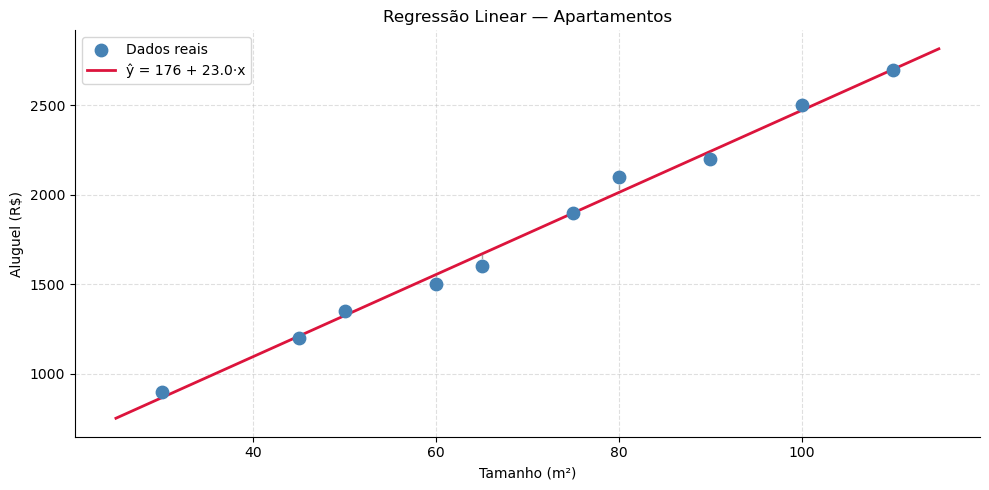

In [10]:
# Reta ajustada sobre os dados originais
x_linha = np.linspace(tamanho.min() - 5, tamanho.max() + 5, 200)
y_linha = prever(x_linha, beta0, beta1)

plt.figure()
plt.scatter(tamanho, aluguel, color='steelblue', s=80, zorder=3, label='Dados reais')
plt.plot(x_linha, y_linha, color='crimson', linewidth=2,
         label=f'ŷ = {beta0:.0f} + {beta1:.1f}·x')

# Resíduos como segmentos verticais
for i in range(len(tamanho)):
    plt.plot(
        [tamanho[i], tamanho[i]],
        [aluguel[i], aluguel_previsto[i]],
        color='gray', linestyle='--', linewidth=1, alpha=0.7
    )

plt.xlabel('Tamanho (m²)')
plt.ylabel('Aluguel (R$)')
plt.title('Regressão Linear — Apartamentos')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [11]:
# Fazendo uma previsão para um apartamento novo
tamanho_novo = 70  # m²
previsao = prever(tamanho_novo, beta0, beta1)

print(f"Previsão para um apartamento de {tamanho_novo} m²:")
print(f"  → Aluguel estimado: R$ {previsao:.2f}")


Previsão para um apartamento de 70 m²:
  → Aluguel estimado: R$ 1783.52


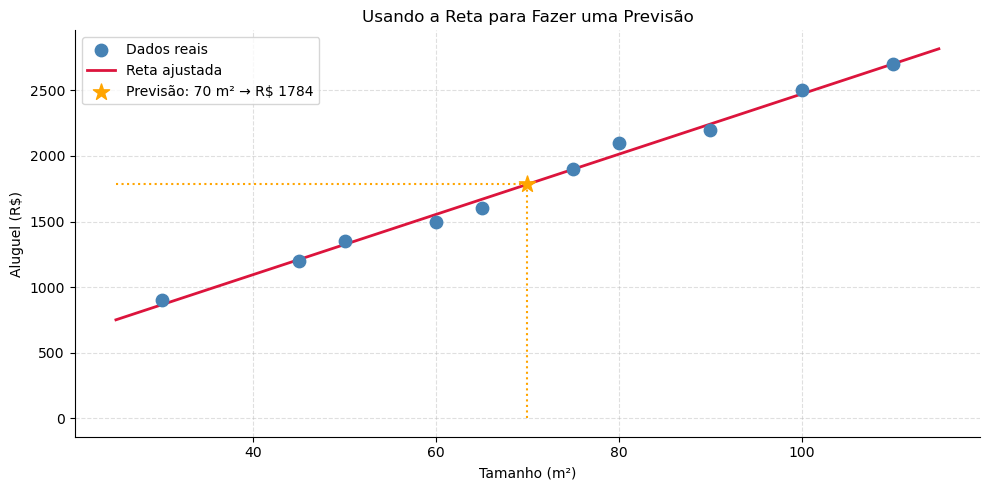

In [12]:
# Visualizando onde cai essa previsão no gráfico
plt.figure()
plt.scatter(tamanho, aluguel, color='steelblue', s=80, zorder=3, label='Dados reais')
plt.plot(x_linha, y_linha, color='crimson', linewidth=2, label='Reta ajustada')

# Marcando a previsão
plt.scatter(tamanho_novo, previsao, color='orange', s=150, zorder=5,
            marker='*', label=f'Previsão: {tamanho_novo} m² → R$ {previsao:.0f}')
plt.plot([tamanho_novo, tamanho_novo], [0, previsao],
         color='orange', linestyle=':', linewidth=1.5)
plt.plot([tamanho.min() - 5, tamanho_novo], [previsao, previsao],
         color='orange', linestyle=':', linewidth=1.5)

plt.xlabel('Tamanho (m²)')
plt.ylabel('Aluguel (R$)')
plt.title('Usando a Reta para Fazer uma Previsão')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



> A estrela laranja é a previsão: para um apartamento de 70 m², o modelo estima um aluguel de aproximadamente R$ 1.800. Note que esse ponto não estava nos dados originais — a reta permite extrapolar para valores novos, desde que estejam dentro de uma faixa razoável (extrapolar muito além dos dados pode ser problemático, assunto para partes futuras).


## 9. Conclusão

### 9.1 Síntese do Projeto

Nesta primeira parte, saímos da intuição e chegamos a um modelo funcional, implementado do zero. O percurso foi:

partimos do problema concreto de prever aluguéis a partir do tamanho de apartamentos, entendemos que uma reta é uma representação matemática natural para relações desse tipo, definimos "melhor reta" como aquela que minimiza a soma dos quadrados dos resíduos (RSS), derivamos as fórmulas dos coeficientes $\beta_0$ e $\beta_1$ diretamente da condição de mínimo, e implementamos tudo isso em Python puro, sem nenhuma biblioteca de machine learning.

Os coeficientes encontrados para o exemplo de apartamentos foram:

| Coeficiente | Valor | Interpretação |
|-------------|-------|---------------|
| $\beta_0$ (intercepto) | calculado no código | valor base da equação |
| $\beta_1$ (angular) | calculado no código | variação no aluguel por m² adicional |

### 9.2 O Que Ficou de Fora (Por Ora)

Fizemos uma regressão com uma única variável de entrada. Na prática, quase sempre temos mais de uma variável relevante: além do tamanho, o aluguel depende do bairro, da idade do imóvel, da quantidade de quartos e por aí vai. Isso é **regressão linear múltipla**, o tema central da Parte 2.

### 9.3 Limitações e Considerações

A regressão linear simples assume que existe uma relação linear entre $x$ e $y$. Se os dados tiverem formato de curva, a reta vai se ajustar mal e os erros serão sistemáticos, não aleatórios. Sempre visualize seus dados antes de aplicar qualquer modelo.

O exemplo aqui usa apenas 10 pontos, o que é pouco para qualquer conclusão robusta. Em situações reais, quanto mais dados, mais confiável é o ajuste.

Por último: o fato de encontrar uma reta com boa aderência aos dados **não significa que existe causalidade**. Tamanho e aluguel têm uma relação plausível do ponto de vista causal, mas em outras situações correlação estatística pode aparecer sem nenhuma relação de causa e efeito. Esse ponto vai aparecer novamente nas partes seguintes.

Este material foi desenvolvido com fins educacionais e é parte do projeto [data-trivium](https://github.com/esscova/data-trivium).